Restarted Project-FitnessTracker (Python 3.8.15)

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from LearningAlgorithms import ClassificationAlgorithms
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [3]:
df = pd.read_pickle("../../data/interim/03_data_features.pkl")

In [4]:
df_train = df.drop(["participant", "category", "set"], axis=1)

In [5]:
x = df_train.drop("label", axis=1)
y = df_train["label"]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)

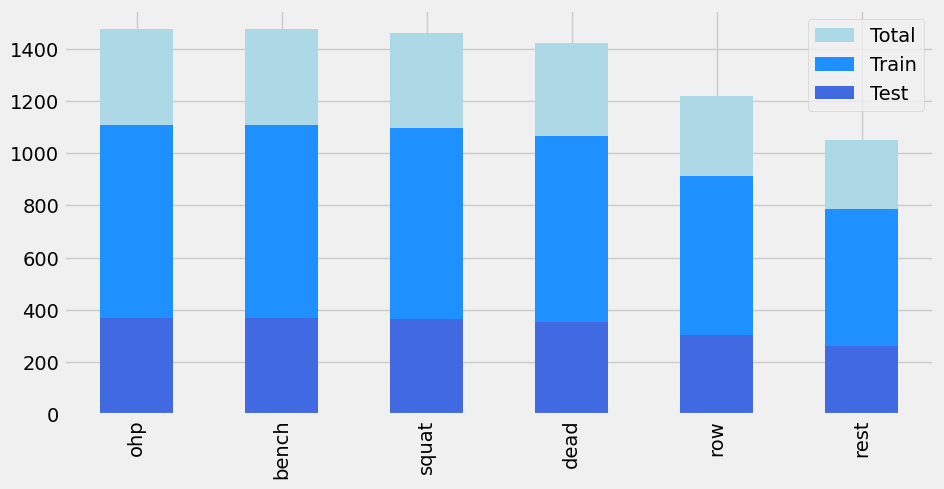

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
df_train["label"].value_counts().plot(
    kind="bar", ax=ax, color="lightblue", label="Total"
)

y_train.value_counts().plot(kind="bar", ax=ax, color="dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color="royalblue", label="Test")
plt.legend()
plt.show()

In [8]:
features_basic = df_train.columns[:6] #JA: 6 - Tot 6
#JA: skip 2 - tot 6 (8)
features_pca = ["pca_1", "pca_2", "pca_3"] #JA: 3 more - tot 9 (11)
features_square = ["acc_r", "gyr_r"] #JA: add 2 - tot 11 (13)
# JA: each column name in df_train, put name into f, then check if
# _temp_ exists in the name, if so put it into the list
features_time = [f for f in df_train.columns if "_temp_" in f] #JA: add 16 - 27 (29)
features_freq = [f for f in df_train.columns if ("_freq" in f) or ("_pse" in f)]
features_clust = ["cluster"]

In [9]:
df_cols = [f for f in df_train.columns] #JA: list of all cols

print("basic:", len(features_basic))
print("square:", len(features_square))
print("pca:", len(features_pca))
print("time:", len(features_time))
print("freq:", len(features_freq))
print("clust:", len(features_clust))

feat_col_num = (len(features_basic)
    + len(features_square)
    + len(features_pca)
    + len(features_time)
    + len(features_freq)
    + len(features_clust))

print("total cols in features:", feat_col_num) #JA: 100 cols
len(df_train.columns) #JA: 102 cols

basic: 6
square: 2
pca: 3
time: 16
freq: 72
clust: 1
total cols in features: 100


102

In [10]:
feature_set_1 = list(set(features_basic))
feature_set_2 = list(set(feature_set_1 + features_square + features_pca))
feature_set_3 = list(set(feature_set_2 + features_time))
feature_set_4 = list(set(feature_set_3 + features_freq + features_clust))

In [11]:
learner = ClassificationAlgorithms()

In [12]:
max_features = 10

In [13]:
features_selected, features_ordered, scores_ordered = learner.forward_selection(features_max, x_train, y_train)

NameError: name 'features_max' is not defined

In [14]:
features_max = 10

In [15]:
features_selected, features_ordered, scores_ordered = learner.forward_selection(features_max, x_train, y_train)

0
1
2
3
4
5
6
7
8
9


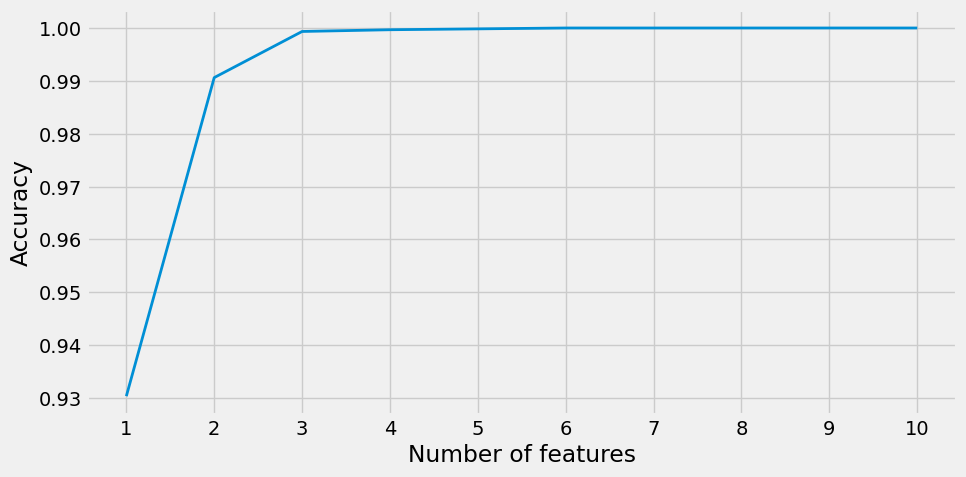

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, features_max + 1, 1), scores_ordered)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, features_max + 1, 1))
plt.show()

In [17]:
features_ordered

['acc_y_freq_0.0_Hz_ws_10',
 'duration',
 'acc_x_freq_0.0_Hz_ws_10',
 'acc_z_temp_mean_ws_5',
 'gyr_r_temp_mean_ws_5',
 'gyr_z_freq_1.0_Hz_ws_10',
 'gyr_x_max_freq',
 'acc_z_pse',
 'gyr_r_freq_2.0_Hz_ws_10',
 'gyr_x_freq_2.5_Hz_ws_10']

In [19]:
scores_ordered

[0.9303589068159368,
 0.990615739216332,
 0.9993414553836022,
 0.9996707276918011,
 0.9998353638459005,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [20]:
features_basic

Index(['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], dtype='object')

In [21]:
features_time

['acc_x_temp_mean_ws_5',
 'acc_x_temp_std_ws_5',
 'acc_y_temp_mean_ws_5',
 'acc_y_temp_std_ws_5',
 'acc_z_temp_mean_ws_5',
 'acc_z_temp_std_ws_5',
 'gyr_x_temp_mean_ws_5',
 'gyr_x_temp_std_ws_5',
 'gyr_y_temp_mean_ws_5',
 'gyr_y_temp_std_ws_5',
 'gyr_z_temp_mean_ws_5',
 'gyr_z_temp_std_ws_5',
 'acc_r_temp_mean_ws_5',
 'acc_r_temp_std_ws_5',
 'gyr_r_temp_mean_ws_5',
 'gyr_r_temp_std_ws_5']

In [22]:
features_freq

['acc_x_max_freq',
 'acc_x_freq_weighted',
 'acc_x_pse',
 'acc_x_freq_0.0_Hz_ws_10',
 'acc_x_freq_0.5_Hz_ws_10',
 'acc_x_freq_1.0_Hz_ws_10',
 'acc_x_freq_1.5_Hz_ws_10',
 'acc_x_freq_2.0_Hz_ws_10',
 'acc_x_freq_2.5_Hz_ws_10',
 'acc_y_max_freq',
 'acc_y_freq_weighted',
 'acc_y_pse',
 'acc_y_freq_0.0_Hz_ws_10',
 'acc_y_freq_0.5_Hz_ws_10',
 'acc_y_freq_1.0_Hz_ws_10',
 'acc_y_freq_1.5_Hz_ws_10',
 'acc_y_freq_2.0_Hz_ws_10',
 'acc_y_freq_2.5_Hz_ws_10',
 'acc_z_max_freq',
 'acc_z_freq_weighted',
 'acc_z_pse',
 'acc_z_freq_0.0_Hz_ws_10',
 'acc_z_freq_0.5_Hz_ws_10',
 'acc_z_freq_1.0_Hz_ws_10',
 'acc_z_freq_1.5_Hz_ws_10',
 'acc_z_freq_2.0_Hz_ws_10',
 'acc_z_freq_2.5_Hz_ws_10',
 'gyr_x_max_freq',
 'gyr_x_freq_weighted',
 'gyr_x_pse',
 'gyr_x_freq_0.0_Hz_ws_10',
 'gyr_x_freq_0.5_Hz_ws_10',
 'gyr_x_freq_1.0_Hz_ws_10',
 'gyr_x_freq_1.5_Hz_ws_10',
 'gyr_x_freq_2.0_Hz_ws_10',
 'gyr_x_freq_2.5_Hz_ws_10',
 'gyr_y_max_freq',
 'gyr_y_freq_weighted',
 'gyr_y_pse',
 'gyr_y_freq_0.0_Hz_ws_10',
 'gyr_y_freq_0.

In [23]:
df_cols

['acc_x',
 'acc_y',
 'acc_z',
 'gyr_x',
 'gyr_y',
 'gyr_z',
 'label',
 'duration',
 'pca_1',
 'pca_2',
 'pca_3',
 'acc_r',
 'gyr_r',
 'acc_x_temp_mean_ws_5',
 'acc_x_temp_std_ws_5',
 'acc_y_temp_mean_ws_5',
 'acc_y_temp_std_ws_5',
 'acc_z_temp_mean_ws_5',
 'acc_z_temp_std_ws_5',
 'gyr_x_temp_mean_ws_5',
 'gyr_x_temp_std_ws_5',
 'gyr_y_temp_mean_ws_5',
 'gyr_y_temp_std_ws_5',
 'gyr_z_temp_mean_ws_5',
 'gyr_z_temp_std_ws_5',
 'acc_r_temp_mean_ws_5',
 'acc_r_temp_std_ws_5',
 'gyr_r_temp_mean_ws_5',
 'gyr_r_temp_std_ws_5',
 'acc_x_max_freq',
 'acc_x_freq_weighted',
 'acc_x_pse',
 'acc_x_freq_0.0_Hz_ws_10',
 'acc_x_freq_0.5_Hz_ws_10',
 'acc_x_freq_1.0_Hz_ws_10',
 'acc_x_freq_1.5_Hz_ws_10',
 'acc_x_freq_2.0_Hz_ws_10',
 'acc_x_freq_2.5_Hz_ws_10',
 'acc_y_max_freq',
 'acc_y_freq_weighted',
 'acc_y_pse',
 'acc_y_freq_0.0_Hz_ws_10',
 'acc_y_freq_0.5_Hz_ws_10',
 'acc_y_freq_1.0_Hz_ws_10',
 'acc_y_freq_1.5_Hz_ws_10',
 'acc_y_freq_2.0_Hz_ws_10',
 'acc_y_freq_2.5_Hz_ws_10',
 'acc_z_max_freq',
 'acc_

In [24]:
features_basic = df_train.columns[:6] #JA: 6 - Tot 6

In [25]:
features_pca = ["pca_1", "pca_2", "pca_3"] #JA: 3 more - tot 9 (11)

In [26]:
features_square = ["acc_r", "gyr_r"] #JA: add 2 - tot 11 (13)

In [27]:
features_time = [f for f in df_train.columns if "_temp_" in f] #JA: add 16 - 27 (29)

In [28]:
features_freq = [f for f in df_train.columns if ("_freq" in f) or ("_pse" in f)]

In [29]:
features_clust = ["cluster"]

In [30]:
feature_set_1 = list(set(features_basic))
feature_set_2 = list(set(feature_set_1 + features_square + features_pca))
feature_set_3 = list(set(feature_set_2 + features_time))
feature_set_4 = list(set(feature_set_3 + features_freq + features_clust))

In [31]:
feature_set_4

['gyr_x_max_freq',
 'gyr_r_freq_2.0_Hz_ws_10',
 'gyr_x_freq_2.0_Hz_ws_10',
 'gyr_r_temp_mean_ws_5',
 'gyr_y_freq_2.0_Hz_ws_10',
 'acc_y_freq_2.0_Hz_ws_10',
 'acc_x_freq_1.5_Hz_ws_10',
 'acc_r_temp_mean_ws_5',
 'acc_r_max_freq',
 'gyr_y_freq_0.5_Hz_ws_10',
 'gyr_x_freq_1.5_Hz_ws_10',
 'acc_y',
 'acc_r_freq_weighted',
 'gyr_z_temp_mean_ws_5',
 'gyr_z_pse',
 'acc_x_freq_weighted',
 'acc_y_temp_mean_ws_5',
 'acc_x_freq_0.5_Hz_ws_10',
 'cluster',
 'acc_y_pse',
 'gyr_y_freq_weighted',
 'acc_z_freq_1.5_Hz_ws_10',
 'pca_2',
 'acc_r_freq_0.0_Hz_ws_10',
 'acc_x_freq_0.0_Hz_ws_10',
 'gyr_y_temp_std_ws_5',
 'acc_r_freq_2.0_Hz_ws_10',
 'gyr_x',
 'acc_z_freq_2.0_Hz_ws_10',
 'gyr_x_freq_weighted',
 'acc_z_max_freq',
 'acc_y_freq_0.0_Hz_ws_10',
 'acc_r_freq_0.5_Hz_ws_10',
 'gyr_r_freq_0.5_Hz_ws_10',
 'pca_1',
 'gyr_x_pse',
 'acc_r_freq_1.0_Hz_ws_10',
 'acc_r_pse',
 'acc_z_temp_std_ws_5',
 'acc_z_freq_2.5_Hz_ws_10',
 'acc_z_freq_1.0_Hz_ws_10',
 'gyr_y_freq_2.5_Hz_ws_10',
 'gyr_z_freq_weighted',
 'gyr_r

In [32]:
feature_set_4["duration"]

TypeError: list indices must be integers or slices, not str

In [33]:
feature_set_4.__contains__

<method-wrapper '__contains__' of list object at 0x00000248D5336940>

In [34]:
feature_set_4.__contains__("Duration")

False

In [35]:
x_train

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,duration,pca_1,pca_2,pca_3,...,gyr_r_max_freq,gyr_r_freq_weighted,gyr_r_pse,gyr_r_freq_0.0_Hz_ws_10,gyr_r_freq_0.5_Hz_ws_10,gyr_r_freq_1.0_Hz_ws_10,gyr_r_freq_1.5_Hz_ws_10,gyr_r_freq_2.0_Hz_ws_10,gyr_r_freq_2.5_Hz_ws_10,cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-20 17:26:09.000,0.241736,-0.933265,0.419478,0.420777,52.680102,-13.619642,39.0,0.369183,0.186978,-0.026731,...,0.0,-0.497030,0.267213,1092.126657,36.959431,-297.590296,-26.838840,-10.884463,-17.814677,0
2019-01-15 19:37:38.000,0.014133,-1.098238,-0.127699,27.388000,0.415970,-8.890706,29.0,0.393190,-0.180331,0.008086,...,0.0,-0.241882,0.583506,220.826214,106.804974,-3.364136,-12.805047,-17.112158,-24.729179,3
2019-01-11 16:24:41.600,0.051957,-1.051448,-0.089264,-1.458571,0.289585,-0.921301,30.0,0.380547,-0.149301,-0.009742,...,0.0,0.551851,0.467110,236.018721,3.245976,60.304609,54.389370,22.808616,9.645300,3
2019-01-16 19:31:02.400,0.056172,-0.915048,0.063469,-30.548488,-8.419687,1.824600,34.0,0.337129,-0.054333,-0.063088,...,0.0,-1.003948,0.415852,189.391581,-11.838087,24.129173,-48.332194,-26.162375,-6.015302,3
2019-01-11 15:14:47.800,-0.082014,0.912185,-0.134212,-10.958998,2.183466,16.995805,14.0,-0.305285,-0.131430,0.027391,...,0.0,-0.069234,0.131811,204.112549,27.616650,-1.266144,-16.830420,1.854483,-2.305994,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-15 19:32:58.000,-0.024617,-0.892660,0.199376,-49.776862,0.361227,2.688395,30.0,0.325442,0.012544,-0.146757,...,0.0,-1.502732,0.277877,252.551522,-21.346323,-11.474722,-43.442920,-17.211356,-29.308465,0
2019-01-15 19:12:04.200,0.289167,0.507930,0.592895,7.949238,-7.943702,-6.131380,20.0,-0.116430,0.344250,0.034196,...,0.0,0.062179,0.074862,111.328631,-4.452752,6.939429,7.770273,-3.132309,-1.123375,2
2019-01-11 16:09:35.600,-0.214481,0.699617,0.268249,17.959595,-3.285848,6.348157,24.0,-0.232969,0.073567,-0.102911,...,0.0,0.231149,0.252581,157.227459,40.253260,2.325476,5.822814,3.871462,4.185668,1


In [36]:
y_train

epoch (ms)
2019-01-20 17:26:09.000     rest
2019-01-15 19:37:38.000     dead
2019-01-11 16:24:41.600     dead
2019-01-16 19:31:02.400     dead
2019-01-11 15:14:47.800    bench
                           ...  
2019-01-15 19:32:58.000     dead
2019-01-15 19:12:04.200    squat
2019-01-11 16:09:35.600    squat
2019-01-14 13:32:26.000    bench
2019-01-11 16:05:54.400    squat
Name: label, Length: 6074, dtype: object

In [37]:
x_train

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,duration,pca_1,pca_2,pca_3,...,gyr_r_max_freq,gyr_r_freq_weighted,gyr_r_pse,gyr_r_freq_0.0_Hz_ws_10,gyr_r_freq_0.5_Hz_ws_10,gyr_r_freq_1.0_Hz_ws_10,gyr_r_freq_1.5_Hz_ws_10,gyr_r_freq_2.0_Hz_ws_10,gyr_r_freq_2.5_Hz_ws_10,cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-20 17:26:09.000,0.241736,-0.933265,0.419478,0.420777,52.680102,-13.619642,39.0,0.369183,0.186978,-0.026731,...,0.0,-0.497030,0.267213,1092.126657,36.959431,-297.590296,-26.838840,-10.884463,-17.814677,0
2019-01-15 19:37:38.000,0.014133,-1.098238,-0.127699,27.388000,0.415970,-8.890706,29.0,0.393190,-0.180331,0.008086,...,0.0,-0.241882,0.583506,220.826214,106.804974,-3.364136,-12.805047,-17.112158,-24.729179,3
2019-01-11 16:24:41.600,0.051957,-1.051448,-0.089264,-1.458571,0.289585,-0.921301,30.0,0.380547,-0.149301,-0.009742,...,0.0,0.551851,0.467110,236.018721,3.245976,60.304609,54.389370,22.808616,9.645300,3
2019-01-16 19:31:02.400,0.056172,-0.915048,0.063469,-30.548488,-8.419687,1.824600,34.0,0.337129,-0.054333,-0.063088,...,0.0,-1.003948,0.415852,189.391581,-11.838087,24.129173,-48.332194,-26.162375,-6.015302,3
2019-01-11 15:14:47.800,-0.082014,0.912185,-0.134212,-10.958998,2.183466,16.995805,14.0,-0.305285,-0.131430,0.027391,...,0.0,-0.069234,0.131811,204.112549,27.616650,-1.266144,-16.830420,1.854483,-2.305994,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-15 19:32:58.000,-0.024617,-0.892660,0.199376,-49.776862,0.361227,2.688395,30.0,0.325442,0.012544,-0.146757,...,0.0,-1.502732,0.277877,252.551522,-21.346323,-11.474722,-43.442920,-17.211356,-29.308465,0
2019-01-15 19:12:04.200,0.289167,0.507930,0.592895,7.949238,-7.943702,-6.131380,20.0,-0.116430,0.344250,0.034196,...,0.0,0.062179,0.074862,111.328631,-4.452752,6.939429,7.770273,-3.132309,-1.123375,2
2019-01-11 16:09:35.600,-0.214481,0.699617,0.268249,17.959595,-3.285848,6.348157,24.0,-0.232969,0.073567,-0.102911,...,0.0,0.231149,0.252581,157.227459,40.253260,2.325476,5.822814,3.871462,4.185668,1


In [38]:
features_selected

['acc_y_freq_0.0_Hz_ws_10',
 'duration',
 'acc_x_freq_0.0_Hz_ws_10',
 'acc_z_temp_mean_ws_5',
 'gyr_r_temp_mean_ws_5',
 'gyr_z_freq_1.0_Hz_ws_10',
 'gyr_x_max_freq',
 'acc_z_pse',
 'gyr_r_freq_2.0_Hz_ws_10',
 'gyr_x_freq_2.5_Hz_ws_10']

In [39]:
scores_ordered

[0.9303589068159368,
 0.990615739216332,
 0.9993414553836022,
 0.9996707276918011,
 0.9998353638459005,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]